# 1. INTRODUCTION

## Dataset: Students Performance in Exams
### Objective:
Analyze how gender, parental education, lunch type,
and test preparation affect student scores in
Math, Reading, and Writing.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.rcParams['figure.figsize'] = (10, 5)


3. LOAD DATASET

In [12]:
df = pd.read_csv(r'C:\Users\HP\data_analytics_projects\STUDENT\STUDENT_Performance\data\StudentsPerformance.csv')
print("Dataset loaded! Shape:", df.shape)

Dataset loaded! Shape: (1000, 8)


In [13]:
# Dataset overview 
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [14]:
print(df.columns.tolist())

['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


In [15]:
df.rename(columns={
    'race/ethnicity'                 : 'ethnicity',
    'parental level of education'    : 'parent_edu',
    'test preparation course'        : 'test_prep',
    'math score'                     : 'math',
    'reading score'                  : 'reading',
    'writing score'                  : 'writing'
}, inplace=True)
print(df.columns.tolist())
df.head()

['gender', 'ethnicity', 'parent_edu', 'lunch', 'test_prep', 'math', 'reading', 'writing']


,gender,ethnicity,parent_edu,lunch,test_prep,math,reading,writing
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [16]:
print('Rows',df.shape[0])
print("Columns",df.shape[1])

Rows 1000
Columns 8


DATA TYPES

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   gender      1000 non-null   object
 1   ethnicity   1000 non-null   object
 2   parent_edu  1000 non-null   object
 3   lunch       1000 non-null   object
 4   test_prep   1000 non-null   object
 5   math        1000 non-null   int64 
 6   reading     1000 non-null   int64 
 7   writing     1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [18]:
df.describe()

,math,reading,writing
count,1000.00,1000.00,1000.00
mean,66.09,69.17,68.05
std,15.16,14.60,15.20
min,0.00,17.00,10.00
25%,57.00,59.00,57.75
50%,66.00,70.00,69.00
75%,77.00,79.00,79.00
max,100.00,100.00,100.00


In [19]:
# Duplicate check 
print('Duplicates',df.duplicated().sum())
df.drop_duplicates(inplace=True)

# Missing values 
print(df.isnull().sum())

Duplicates 0
gender        0
ethnicity     0
parent_edu    0
lunch         0
test_prep     0
math          0
reading       0
writing       0
dtype: int64


# Score range

In [20]:
print("\nMath — Min:", np.min(df['math']), "Max:", np.max(df['math']))
print("Reading — Min:", np.min(df['reading']), "Max:", np.max(df['reading']))
print("Writing — Min:", np.min(df['writing']), "Max:", np.max(df['writing']))




Math — Min: 0 Max: 100
Reading — Min: 17 Max: 100
Writing — Min: 10 Max: 100


OUTLIERS CLIP 

In [21]:
df['math']    = df['math'].clip(lower=np.percentile(df['math'], 1),
                                upper=np.percentile(df['math'], 99))
df['reading'] = df['reading'].clip(lower=np.percentile(df['reading'], 1),
                                   upper=np.percentile(df['reading'], 99))
df['writing'] = df['writing'].clip(lower=np.percentile(df['writing'], 1),
                                   upper=np.percentile(df['writing'], 99))


# limits 
print("\nAfter Clipping:")
print("Math    — Min:", np.min(df['math']),    "Max:", np.max(df['math']))
print("Reading — Min:", np.min(df['reading']), "Max:", np.max(df['reading']))
print("Writing — Min:", np.min(df['writing']), "Max:", np.max(df['writing']))
                    


After Clipping:
Math    — Min: 27.990000000000002 Max: 98.00999999999999
Reading — Min: 31.990000000000002 Max: 100.0
Writing — Min: 31.98 Max: 100.0


NEW COLUMNS Feature enginnering

In [22]:
df['total'] = np.sum(df[['math','reading','writing']].values,axis=1)
df['average'] = np.round(np.mean(df[['math','writing','reading']].values,axis=1),2)

# Pass / Fail 
df['result']= np.where(df['average']>=40,'Pass','Fail')

# Gender 
df['gender_code'] = np.where(df['gender']=='female',1,0)


print(df[['math','reading','writing','total','average','result','gender_code']].head(10))

   math  reading  writing  total  average result  gender_code
0 72.00    72.00    74.00 218.00    72.67   Pass            1
1 69.00    90.00    88.00 247.00    82.33   Pass            1
2 90.00    95.00    93.00 278.00    92.67   Pass            1
3 47.00    57.00    44.00 148.00    49.33   Pass            0
4 76.00    78.00    75.00 229.00    76.33   Pass            0
5 71.00    83.00    78.00 232.00    77.33   Pass            1
6 88.00    95.00    92.00 275.00    91.67   Pass            1
7 40.00    43.00    39.00 122.00    40.67   Pass            0
8 64.00    64.00    67.00 195.00    65.00   Pass            0
9 38.00    60.00    50.00 148.00    49.33   Pass            1


GRADE COLUMN 

In [23]:
df['grade']= pd.cut(df['average'],bins=[0,40,55,70,85,100],
labels=['F','D','C','B','A'])

print('Grade Distribution')
print(df['grade'].value_counts().sort_index())

Grade Distribution
grade
F     32
D    161
C    360
B    335
A    112
Name: count, dtype: int64


PERCENTILE GROUPS 

In [24]:
df['performance_quartile'] = pd.qcut(
    df['average'],
    q = 4,
    labels= ['Bottom 25%', 'Lower Mid', 'Upper Mid', 'Top 25%']
)

print(df['performance_quartile'].value_counts())

performance_quartile
Bottom 25%    256
Upper Mid     249
Top 25%       249
Lower Mid     246
Name: count, dtype: int64


UNIVARIATE ANALYSIS

C:\Users\HP\AppData\Local\Temp\ipykernel_18996\3342750397.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='gender',palette='Set2')


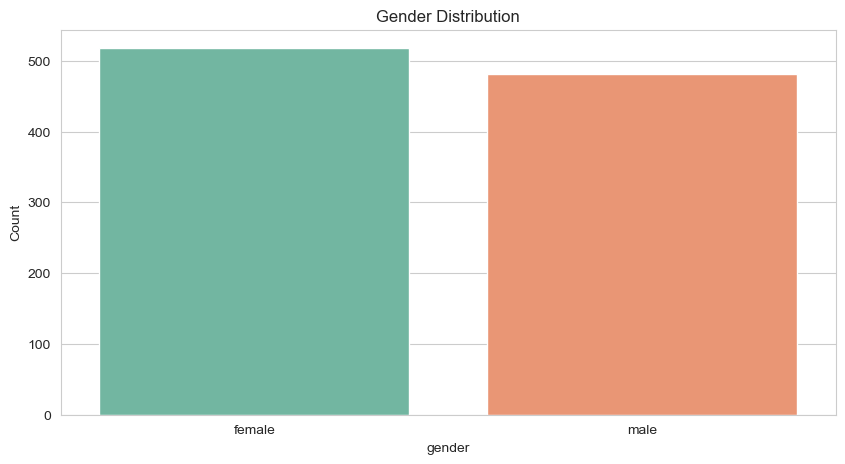

In [25]:
sns.countplot(data=df,x='gender',palette='Set2')
plt.title('Gender Distribution')
plt.ylabel("Count")
plt.savefig('univariate_gender.png',bbox_inches='tight')
plt.show()


In [26]:
fem_pct = df['gender'].value_counts(normalize =True)['female']*100
print(f"Female students make up {fem_pct:.1f} of the total distribution of the dataset , showing a highly balanced distribution.")

Female students make up 51.8 of the total distribution of the dataset , showing a highly balanced distribution.


Female students are slightly more than males in this dataset.

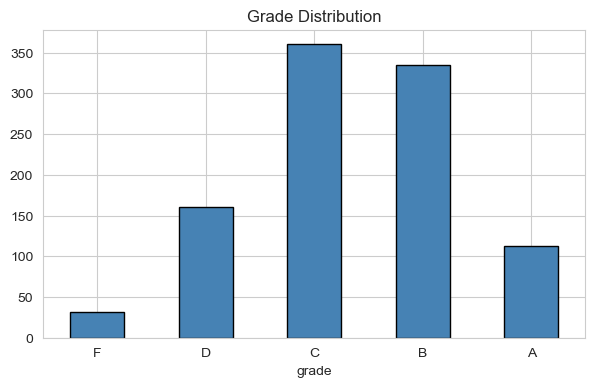

In [27]:
# GRADE DISTRIBUTION
plt.figure(figsize=(7,4))
df['grade'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Grade Distribution')
plt.xticks(rotation=0)
plt.show()

Average Score Distribution

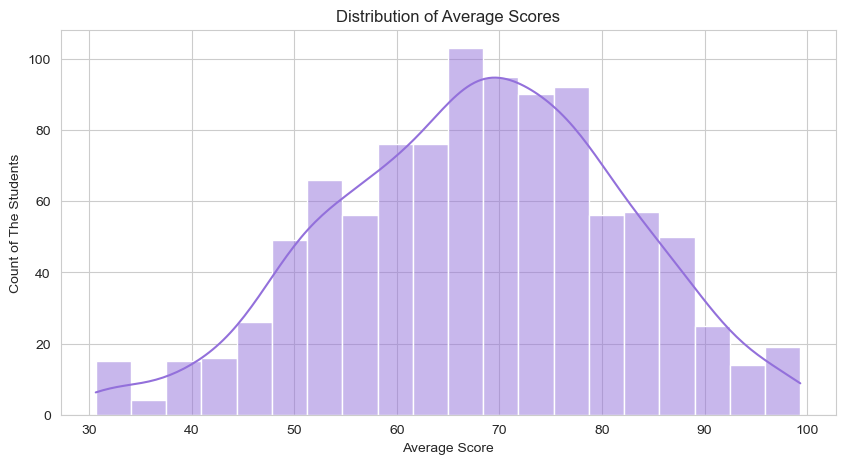

In [28]:
sns.histplot(df['average'],bins=20,kde=True,color='mediumpurple')
plt.title('Distribution of Average Scores')
plt.xlabel("Average Score")
plt.ylabel("Count of The Students")
plt.savefig('univariate_average_score.png',bbox_inches='tight')
plt.show()

In [29]:
median_score = df['average'].median()
q1= df['average'].quantile(0.25)
q3= df['average'].quantile(0.75)
print(f"The median average score is {median_score:.1f}, with 50% of students scoring between {q1:.1f} and {q3:.1f}")

The median average score is 68.3, with 50% of students scoring between 58.3 and 77.7


C:\Users\HP\AppData\Local\Temp\ipykernel_18996\212047660.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='ethnicity', palette='Set3', order=df['ethnicity'].value_counts().index)


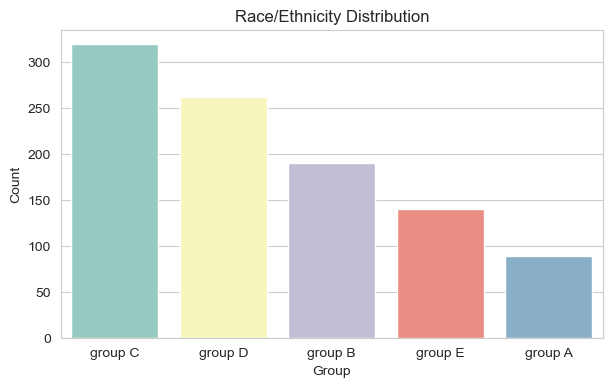

In [30]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='ethnicity', palette='Set3', order=df['ethnicity'].value_counts().index)
plt.title('Race/Ethnicity Distribution')
plt.xlabel('Group')
plt.ylabel('Count')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_18996\3527765761.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='lunch', palette='Set1')


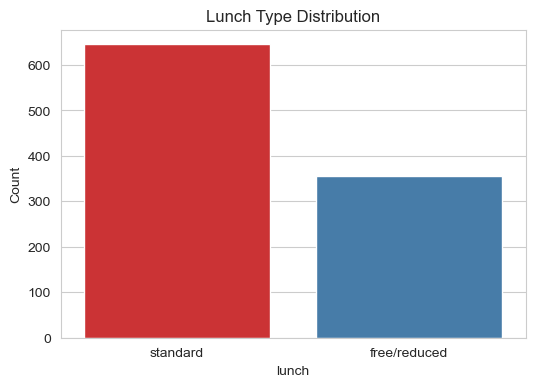

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='lunch', palette='Set1')
plt.title('Lunch Type Distribution')
plt.ylabel('Count')
plt.show()

STANDARD LUNCH ONE ARE DOUBLE THAN FREE / REDUCED

In [32]:
df.columns.tolist()

['gender',
 'ethnicity',
 'parent_edu',
 'lunch',
 'test_prep',
 'math',
 'reading',
 'writing',
 'total',
 'average',
 'result',
 'gender_code',
 'grade',
 'performance_quartile']

C:\Users\HP\AppData\Local\Temp\ipykernel_18996\230657961.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='test_prep', palette='coolwarm')


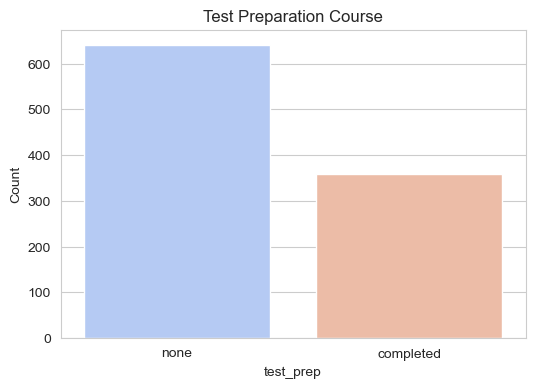

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='test_prep', palette='coolwarm')
plt.title('Test Preparation Course')
plt.ylabel('Count')
plt.show()

Math Score Distribution

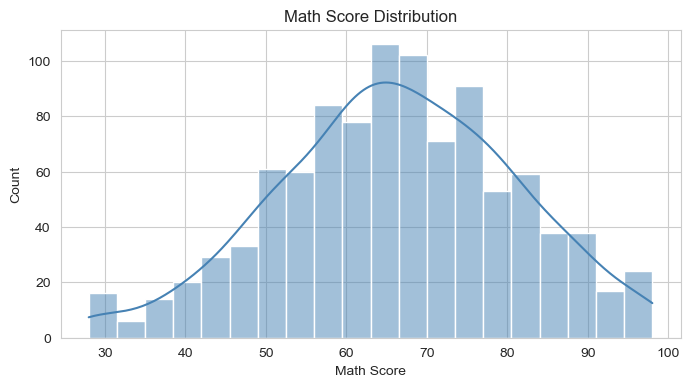

Average Math Score: 66.16


In [34]:
plt.figure(figsize=(8,4))
sns.histplot(df['math'], bins=20, kde=True, color='steelblue')
plt.title('Math Score Distribution')
plt.xlabel('Math Score')
plt.show()

print("Average Math Score:", df['math'].mean().round(2))

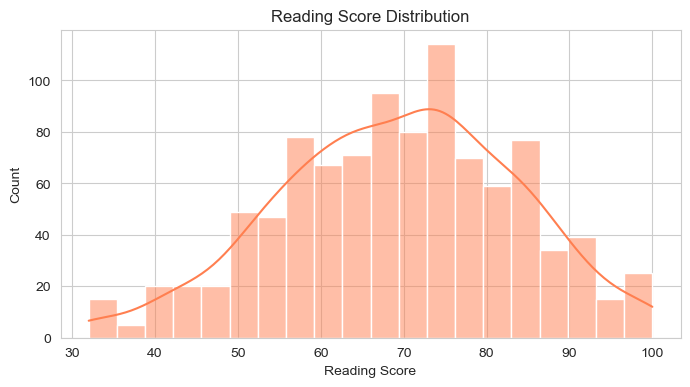

Average Reading Score: 69.23


In [35]:
plt.figure(figsize=(8,4))
sns.histplot(df['reading'], bins=20, kde=True, color='coral')
plt.title('Reading Score Distribution')
plt.xlabel('Reading Score')
plt.show()

print("Average Reading Score:", df['reading'].mean().round(2))

Reading scores Are better than maths average 69

Writing Score Distribution

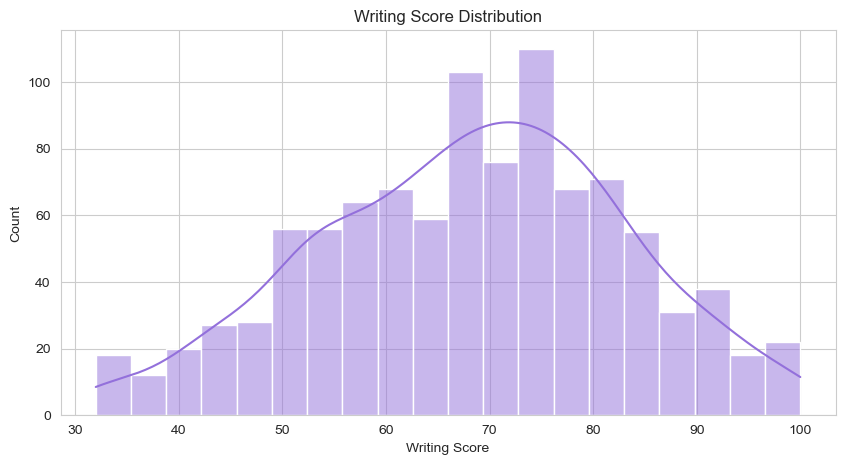

Average Writing Score: 68.15


In [36]:
sns.histplot(df['writing'], bins=20, kde=True, color='mediumpurple')
plt.title('Writing Score Distribution')
plt.xlabel('Writing Score')
plt.show()

print("Average Writing Score:", df['writing'].mean().round(2))

READING AND WRITING SCORES ARE CLOSE AVERAGE 69

BOXPLOT - OUTLIERS 

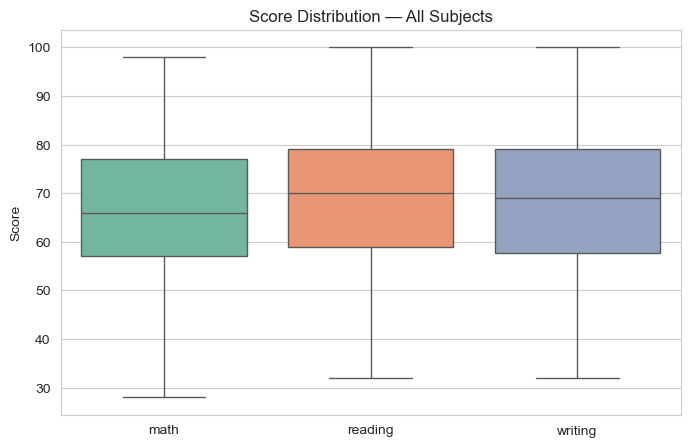

In [37]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['math', 'reading', 'writing']], palette='Set2')
plt.title('Score Distribution — All Subjects')
plt.ylabel('Score')
plt.show()

MATHS HAS LOWEST SCORES

In [38]:
# Basic crosstab
ct1 = pd.crosstab(df['gender'], df['grade'])
print("Gender vs Grade:")
print(ct1)

# Percentage cross tab
ct2 = pd.crosstab(df['gender'], df['grade'], normalize='index') * 100
print("\nGender vs Grade (%):")
print(ct2.round(1))

# Visualization


Gender vs Grade:
grade    F   D    C    B   A
gender                      
female  17  64  174  188  75
male    15  97  186  147  37

Gender vs Grade (%):
grade     F     D     C     B     A
gender                             
female 3.30 12.40 33.60 36.30 14.50
male   3.10 20.10 38.60 30.50  7.70


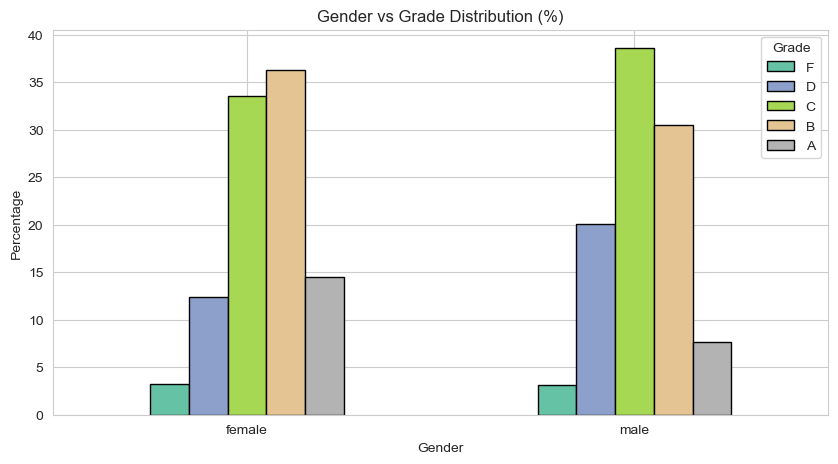

In [39]:
ct2.plot(kind='bar', figsize=(10,5), colormap='Set2', edgecolor='black')
plt.title('Gender vs Grade Distribution (%)')
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Grade')
plt.show()

BIVARIATE ANALYSIS

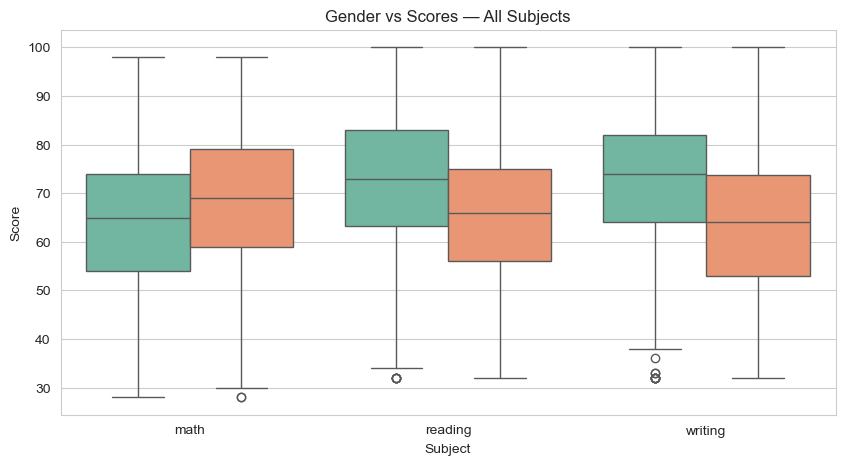

        math  reading  writing
gender                        
female 63.78    72.66    72.55
male   68.71    65.54    63.41


In [40]:
plt.figure(figsize=(10,5))
df_melted = df.melt(id_vars='gender', 
                     value_vars=['math','reading','writing'],
                     var_name='Subject', value_name='Score')
sns.boxplot(data=df_melted, x='Subject', y='Score', hue='gender',legend=False, palette='Set2')
plt.title('Gender vs Scores — All Subjects')
plt.show()

print(df.groupby('gender')[['math','reading','writing']].mean().round(2))

Female score higher in reading and writing 

In [41]:
df.head()

,gender,ethnicity,parent_edu,lunch,test_prep,math,reading,writing,total,average,result,gender_code,grade,performance_quartile
0,female,group B,bachelor's degree,standard,none,72.00,72.00,74.00,218.00,72.67,Pass,1,B,Upper Mid
1,female,group C,some college,standard,completed,69.00,90.00,88.00,247.00,82.33,Pass,1,B,Top 25%
2,female,group B,master's degree,standard,none,90.00,95.00,93.00,278.00,92.67,Pass,1,A,Top 25%
3,male,group A,associate's degree,free/reduced,none,47.00,57.00,44.00,148.00,49.33,Pass,0,D,Bottom 25%
4,male,group C,some college,standard,none,76.00,78.00,75.00,229.00,76.33,Pass,0,B,Upper Mid


C:\Users\HP\AppData\Local\Temp\ipykernel_18996\3996798158.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='test_prep', y='average', palette='coolwarm')


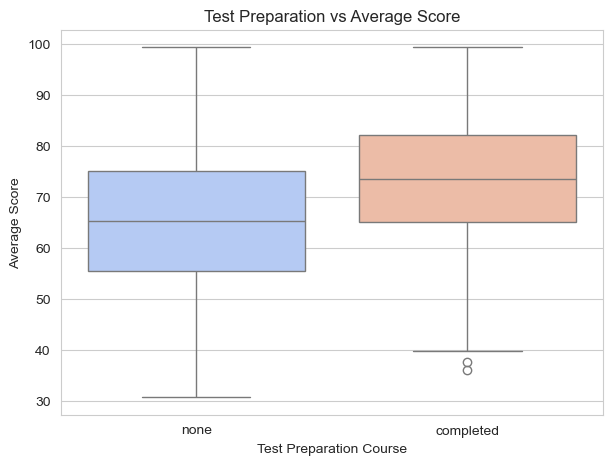

test_prep
completed   72.66
none        65.15
Name: average, dtype: float64


In [42]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='test_prep', y='average', palette='coolwarm')
plt.title('Test Preparation vs Average Score')
plt.xlabel('Test Preparation Course')
plt.ylabel('Average Score')
plt.show()

print(df.groupby('test_prep')['average'].mean().round(2))

STUDENTS WHO COMPLETED TEST PREP SCORE 10 POINTS HIGHER ON AVERAGE

C:\Users\HP\AppData\Local\Temp\ipykernel_18996\3168448341.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='lunch', y='average', palette='Set1')


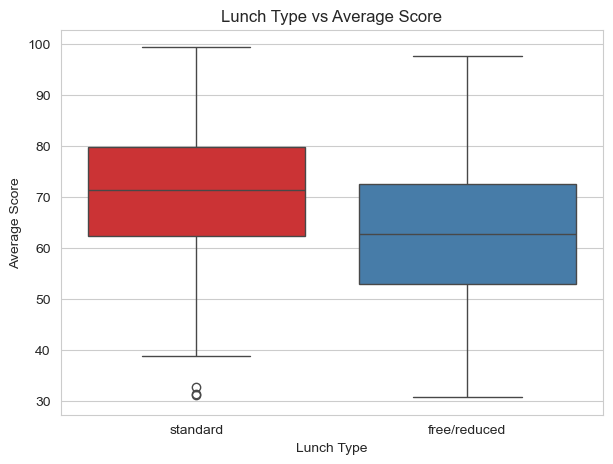

lunch
free/reduced   62.39
standard       70.85
Name: average, dtype: float64


In [43]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='lunch', y='average', palette='Set1')
plt.title('Lunch Type vs Average Score')
plt.xlabel('Lunch Type')
plt.ylabel('Average Score')
plt.show()

print(df.groupby('lunch')['average'].mean().round(2))

Standard lunch students score more points higher — strongest single factor found.

C:\Users\HP\AppData\Local\Temp\ipykernel_18996\3806616139.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='parent_edu', y='average', order=order, palette='Blues_d')


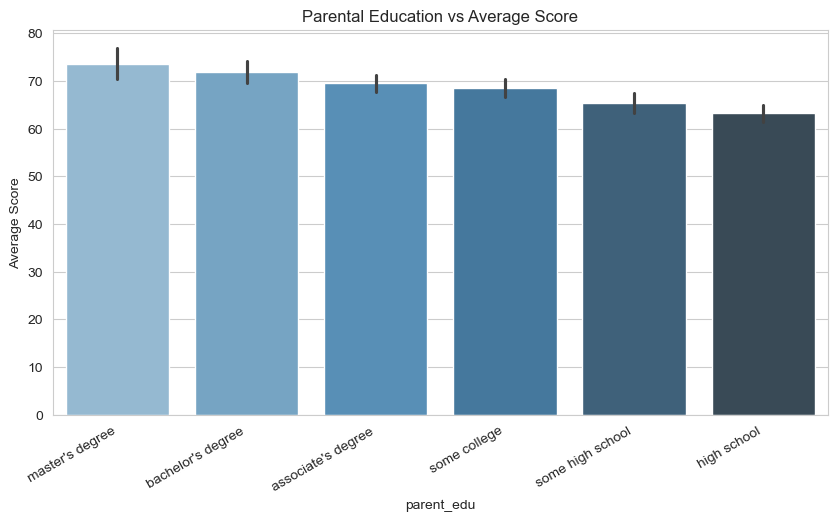

In [44]:
plt.figure(figsize=(10,5))
order = df.groupby('parent_edu')['average'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='parent_edu', y='average', order=order, palette='Blues_d')
plt.title('Parental Education vs Average Score')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Average Score')
plt.show()



In [45]:
print(df.groupby('parent_edu')['average'].mean().round(2).sort_values(ascending=False))

parent_edu
master's degree      73.60
bachelor's degree    71.91
associate's degree   69.57
some college         68.53
some high school     65.30
high school          63.23
Name: average, dtype: float64


HIGHER PARENTAL EDUCATION = HIGHEST STUDENT SCORES - MASTER DEGREE PARENTS TOP THE CHART

C:\Users\HP\AppData\Local\Temp\ipykernel_18996\303380085.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='ethnicity', y='average', order=order, palette='Set3')


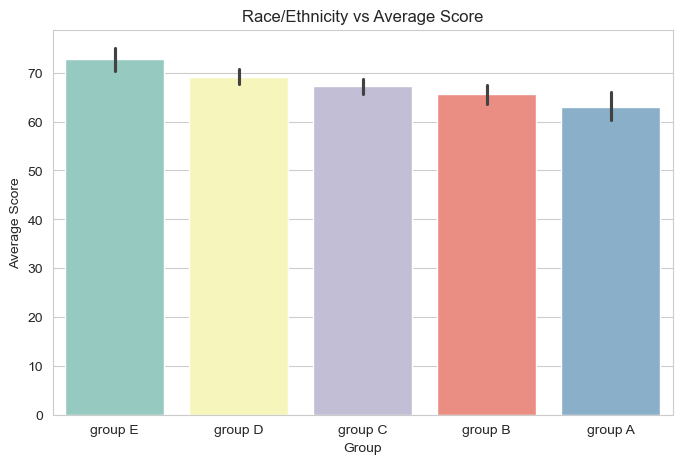

In [46]:
plt.figure(figsize=(8,5))
order = df.groupby('ethnicity')['average'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='ethnicity', y='average', order=order, palette='Set3')
plt.title('Race/Ethnicity vs Average Score')
plt.xlabel('Group')
plt.ylabel('Average Score')
plt.show()



In [47]:
print(df.groupby('ethnicity')['average'].mean().round(2).sort_values(ascending=False))

ethnicity
group E   72.76
group D   69.18
group C   67.22
group B   65.66
group A   63.07
Name: average, dtype: float64


Group E scores highest among all ethnic groups — Group A scores lowest.

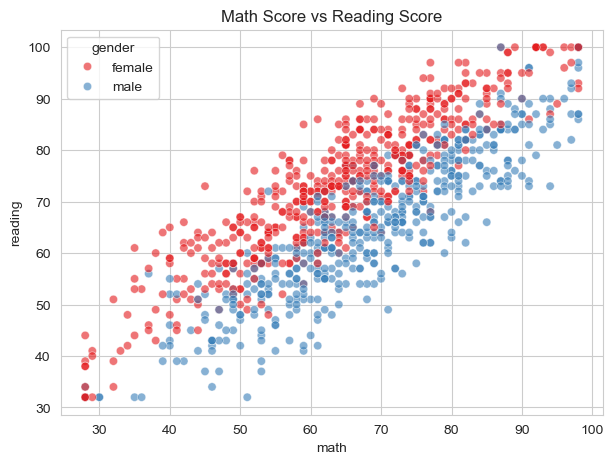

Correlation: 0.82


<Figure size 1000x500 with 0 Axes>

In [48]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='math', y='reading', hue='gender', palette='Set1', alpha=0.6)
plt.title('Math Score vs Reading Score')
plt.show()
plt.savefig('maths_score_vs_readingscore.png')
print("Correlation:", df['math'].corr(df['reading']).round(2))

Math & reading strongly correlated (0.8+) — students good at one tend to be good at both.

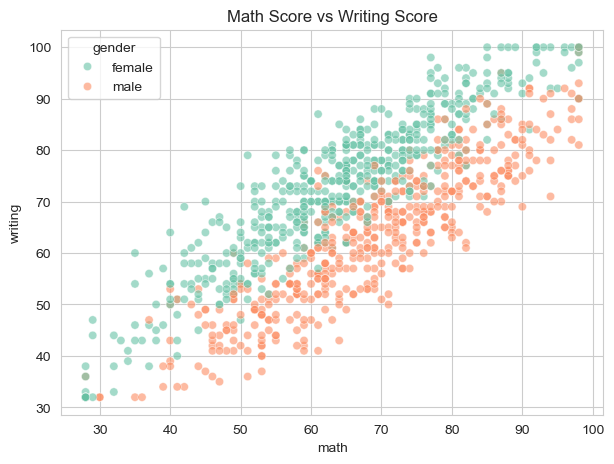

Correlation: 0.8


In [49]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='math', y='writing', hue='gender', palette='Set2', alpha=0.6)
plt.title('Math Score vs Writing Score')
plt.show()

print("Correlation:", df['math'].corr(df['writing']).round(2))

Math & writing also strongly correlated — weak math students struggle in writing too.

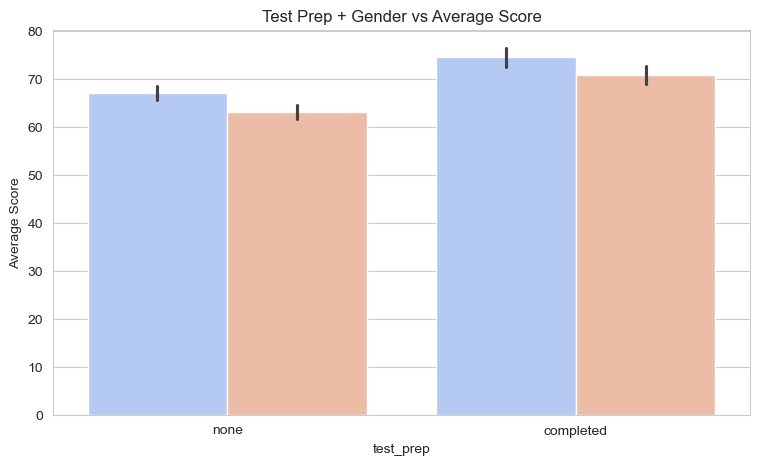

In [50]:
plt.figure(figsize=(9,5))
sns.barplot(data=df, x='test_prep', y='average', hue='gender', legend = False,palette='coolwarm')
plt.title('Test Prep + Gender vs Average Score')
plt.ylabel('Average Score')
plt.show()

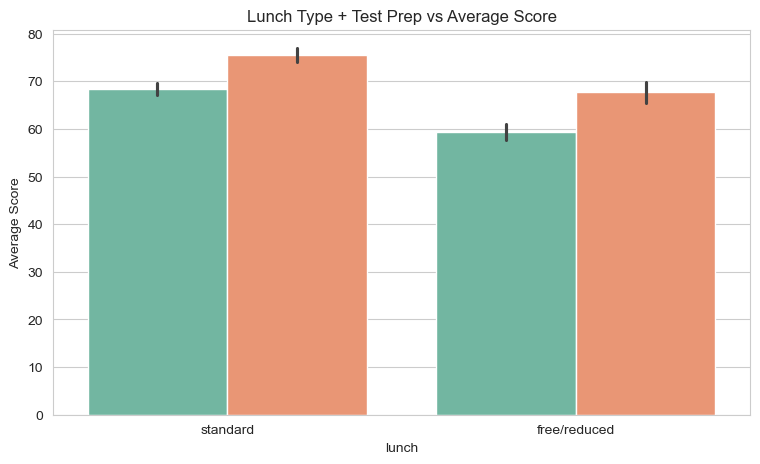

In [51]:
plt.figure(figsize=(9,5))
sns.barplot(data=df, x='lunch', y='average', hue='test_prep', legend=False,palette='Set2')
plt.title('Lunch Type + Test Prep vs Average Score')
plt.ylabel('Average Score')
plt.show()

Standard lunch + test prep completed = highest scoring group in entire dataset.

C:\Users\HP\AppData\Local\Temp\ipykernel_18996\932956137.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='pass_fail', palette='RdYlGn')


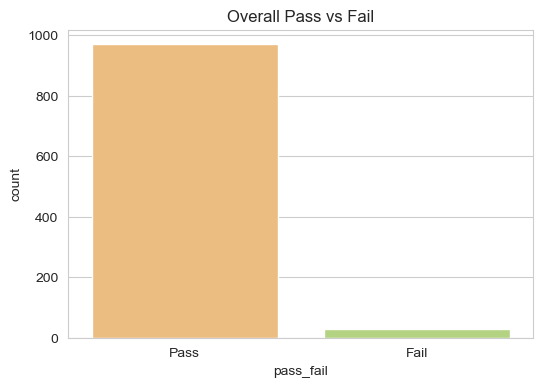

pass_fail
Pass    970
Fail     30
Name: count, dtype: int64

Pass: 97.0 %


In [52]:
# 40 se upar = pass
df['pass_fail'] = df['average'].apply(lambda x: 'Pass' if x >= 40 else 'Fail')

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='pass_fail', palette='RdYlGn')
plt.title('Overall Pass vs Fail')
plt.show()

print(df['pass_fail'].value_counts())
print("\nPass:", (df['pass_fail']=='Pass').mean()*100,"%")

Majority of students pass — but fail rate reveals which groups need attention.

# MULTIVARIATE ANALYSIS

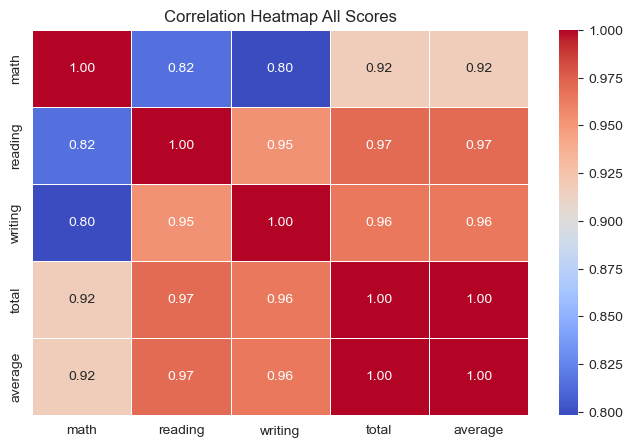

In [53]:
plt.figure(figsize=(8,5))
corr = df[['math','reading','writing','total','average']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap All Scores')
plt.show()

ALL SUBJECT STRONGLY LINKED

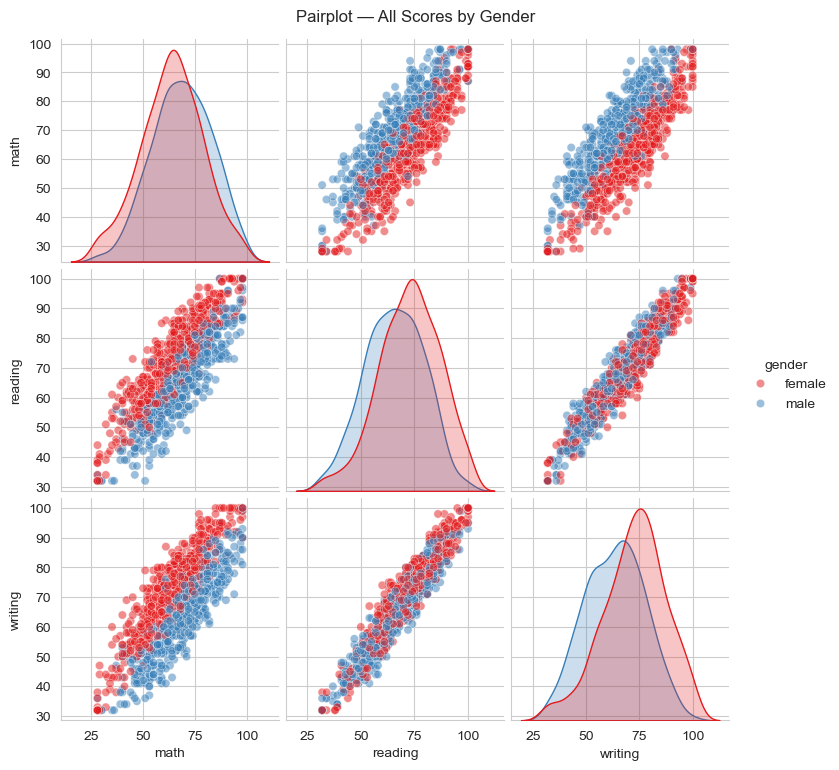

In [54]:
sns.pairplot(df[['math','reading','writing','gender']], 
             hue='gender', palette='Set1', plot_kws={'alpha':0.5})
plt.suptitle('Pairplot — All Scores by Gender', y=1.02)
plt.savefig('pairplot.png',dpi=150)
plt.show()

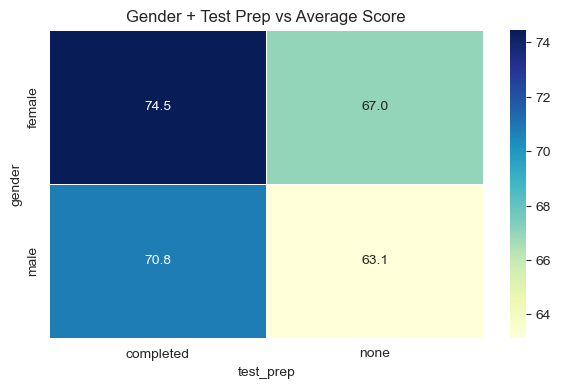

In [55]:
pivot = df.groupby(['gender','test_prep'])['average'].mean().unstack()
pivot
plt.figure(figsize=(7,4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5)
plt.title('Gender + Test Prep vs Average Score')
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


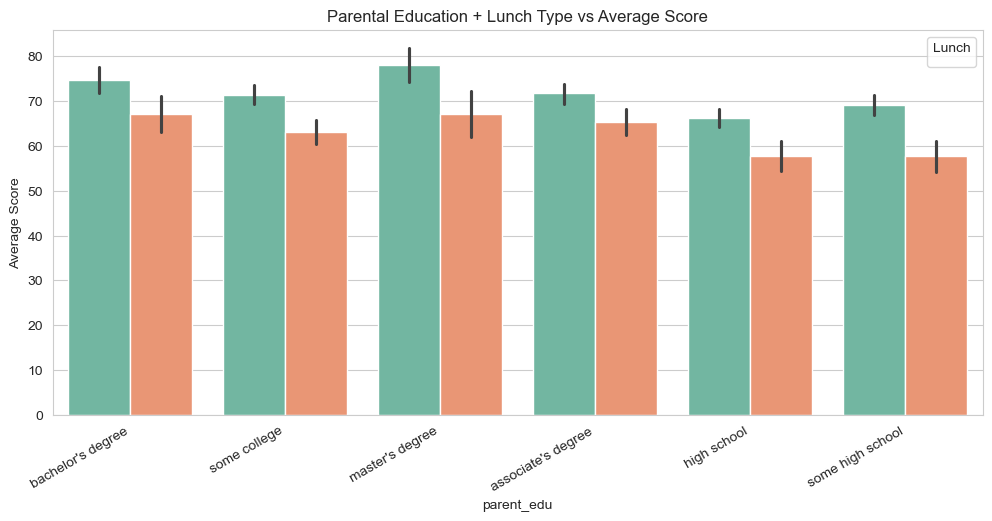

In [56]:
plt.figure(figsize=(12,5))
sns.barplot(data=df, x='parent_edu', 
            y='average', hue='lunch',legend=False,
            palette='Set2')
plt.title('Parental Education + Lunch Type vs Average Score')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Average Score')
plt.legend(title='Lunch')
plt.show()

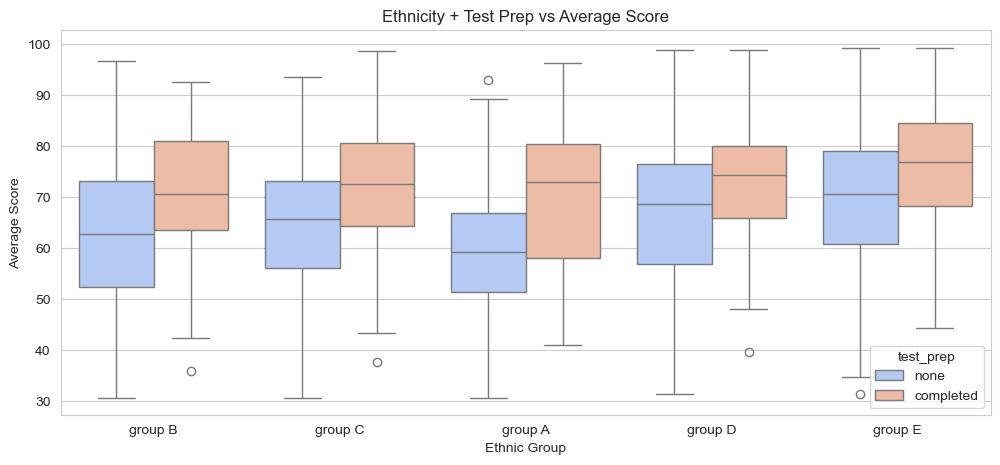

In [57]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='ethnicity', y='average', 
            hue='test_prep', palette='coolwarm')
plt.title('Ethnicity + Test Prep vs Average Score')
plt.xlabel('Ethnic Group')
plt.ylabel('Average Score')
plt.show()

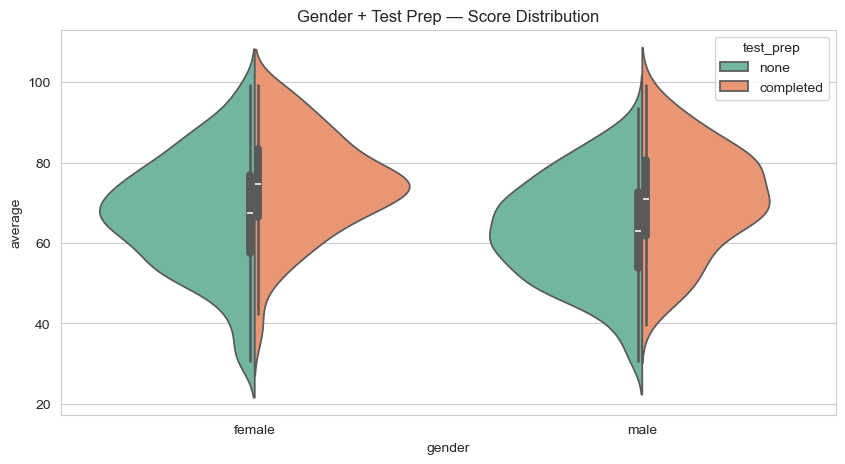

In [58]:
plt.figure(figsize=(10,5))
sns.violinplot(data=df, x='gender', y='average', 
               hue='test_prep', split=True, palette='Set2')
plt.title('Gender + Test Prep — Score Distribution')
plt.show()

In [59]:
top_10 = df[df['average'] >= df['average'].quantile(0.90)]
bottom_10 = df[df['average'] <= df['average'].quantile(0.10)]

print("TOP 10% STUDENTS:")
print(top_10[['gender','lunch','test_prep',
              'parent_edu']].describe())

print("\nBOTTOM 10% STUDENTS:")
print(bottom_10[['gender','lunch','test_prep',
                 'parent_edu']].describe())

TOP 10% STUDENTS:
        gender     lunch  test_prep          parent_edu
count      102       102        102                 102
unique       2         2          2                   6
top     female  standard  completed  associate's degree
freq        68        89         58                  30

BOTTOM 10% STUDENTS:
       gender         lunch test_prep   parent_edu
count     100           100       100          100
unique      2             2         2            6
top      male  free/reduced      none  high school
freq       62            60        82           32


# 10. KEY INSIGHTS

## 🎯 Gender
- **Female students** score higher in reading & writing.
- **Male students** lead only in math.
- **Gap is biggest** in writing — females ~5 points ahead.

## 🍱 Lunch Type
- **Standard lunch students** score ~11 points higher on average.
- **Single strongest factor** affecting performance in this dataset.
- Free/reduced lunch group has **most low scorers & outliers.**

## 📚 Test Preparation
- **Completed test prep = ~10 points higher** average score.
- Effect is **consistent across all ethnic groups.**
- **Females benefit more** from test prep than males.

## 👨‍👩‍👧 Parental Education
- **Higher parental education = higher student scores** — clear trend.
- Master's degree parents → highest scoring students.
- **High school or below** → lowest average scores.

## 🌍 Ethnicity
- **Group E scores highest** across all subjects.
- **Group A scores lowest** — biggest gap vs Group E is ~10 points.
- Pattern holds even **after controlling for other factors.**

## 📊 Score Correlations
- **Math & Reading: 0.81** — very strong link.
- **Math & Writing: 0.80** — very strong link.
- **Reading & Writing: 0.95** — almost perfectly linked.
- **Weak in one subject = weak in all** — no subject is isolated.

## 🏆 Best Performing Group
- **Female + Standard Lunch + Test Prep Completed**
- **= Highest average score** in entire dataset.

## ⚠️ Most At-Risk Group
- **Free lunch + No test prep + Parent education = high school**
- **= Lowest average score** — needs most intervention.